In [48]:
!pip install torch transformers scikit-learn pandas numpy matplotlib plotly spacy
!python -m spacy download nl_core_news_sm
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install --upgrade "transformers[torch]"
!pip install tqdm
!pip install Datasets
!pip install seaborn

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ----- ---------------------------------- 1.8/12.8 MB 11.2 MB/s eta 0:00:01
     ------------ --------------------------- 3.9/12.8 MB 9.8 MB/s eta 0:00:01
     ------------------ --------------------- 6.0/12.8 MB 10.0 MB/s eta 0:00:01
     -------------------------- ------------- 8.4/12.8 MB 10.2 MB/s eta 0:00:01
     --------------------------------- ----- 11.0/12.8 MB 10.6 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 10.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('nl_core_news_sm')
Looking in indexes: https://download.pytorch.org/whl/cu121


##Run LDAprecoding_script

In [95]:
#Run LDAprecoding_script

import json

config = {
    "USE_FOLDER": True,
    "SOURCE_FOLDER_PATH": "sources",
    "OUTPUT_FOLDER": "Corex_topicdata_slavery_v2",
    "MODEL_FOLDER": "Corex_topicdata_slavery_v2",
    "FOLDER_MODE": True,  # Set to True if you want to use simple mode
    "YEAR_FILTER": [],
    "DOC_TYPES": [],
    "SENTS_PER_CHUNK": 5,
    "CONFIDENCE_THRESHOLD": 0.4,
    "MIN_COSINE": 0.05
}

with open("corex_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)




In [37]:
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import json
import os

# ---- Set your folders here ----
OUTPUT_FOLDER = "Policyarchive/corex_chunk5_slavery1"
MODEL_FOLDER = "Corex_model_slavery1"

RESULTS_CSV = os.path.join(OUTPUT_FOLDER, "chunk_topic_corex_assignments.csv")
TOPICDATA_JSON = os.path.join(MODEL_FOLDER, "lda_topicdata.json")

# --- Load results ---
train_source = pd.read_csv(RESULTS_CSV)

# --- Load topic names and wordlists ---
with open(TOPICDATA_JSON, "r", encoding="utf-8") as f:
    topicdata = json.load(f)
topic_names = topicdata["topic_names"]
topic_word_lists = topicdata["topic_word_lists"]

In [39]:
#summary LDA results


# ========== 1. Average chunk length in 5-letter words ==========
def chunk_length_in_5letter_words(text):
    words = str(text).split()
    return sum(max(1, len(w)//5) for w in words)  # Each 5 chars = 1 "word"

df=train_source


df['chunk_5w_len'] = df['chunk_text'].apply(chunk_length_in_5letter_words)
print(f"Overall average chunk length (in 5-letter words): {df['chunk_5w_len'].mean():.2f}")

print("\n--- Average chunk length (per topic) ---")
for t in topic_names:
    sub = df[df['topic'] == t]
    avg_len = sub['chunk_5w_len'].mean() if not sub.empty else 0
    print(f"{t:40s}: {avg_len:.2f}")

# ========== 2. Spread over files / Most present file per topic ==========
print("\n--- Chunks per file (overall) ---")
file_counts = df['filename'].value_counts()
print(file_counts.head(10))

print("\n--- Chunks per file (per topic) & Most present file per topic ---")
for t in topic_names:
    sub = df[df['topic'] == t]
    file_counts = sub['filename'].value_counts()
    if not file_counts.empty:
        print(f"\n[{t}] (total: {len(sub)})")
        print(file_counts.head(5))
        print(f"  Most present file: {file_counts.idxmax()} ({file_counts.max()} chunks)")
    else:
        print(f"\n[{t}] No chunks found.")

# ========== 3. Cosine similarity of each chunk to anchor word set (per topic) ==========
print("\n--- Cosine Similarity to Topic Anchors (TF-IDF, per topic) ---")
tfidf = TfidfVectorizer()
topic_anchor_docs = [' '.join(words) for words in topic_word_lists]
topic_anchor_vecs = tfidf.fit_transform(topic_anchor_docs)

avg_sims_per_topic = []
for i, t in enumerate(topic_names):
    sub = df[df['topic'] == t]
    if sub.empty:
        avg_sims_per_topic.append(0)
        print(f"{t:40s}: N/A")
        continue
    chunk_vecs = tfidf.transform(sub['chunk_text'].astype(str))
    sims = cosine_similarity(chunk_vecs, topic_anchor_vecs[i])
    avg_sim = np.mean(sims)
    avg_sims_per_topic.append(avg_sim)
    print(f"{t:40s}: {avg_sim:.3f}")

# ========== 4. Average number of keywords present (per topic) ==========
print("\n--- Average # Topic Keywords in Chunk (per topic) ---")
def count_topic_keywords(chunk, topic_word_list):
    chunk_tokens = set(str(chunk).lower().split())
    anchors = set(topic_word_list)
    return len(chunk_tokens & anchors)

for i, t in enumerate(topic_names):
    sub = df[df['topic'] == t]
    if sub.empty:
        print(f"{t:40s}: N/A")
        continue
    avg_kw = sub['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
    print(f"{t:40s}: {avg_kw:.2f}")

# ========== (OPTIONAL) Show summary as table ==========
summary = pd.DataFrame({
    "topic": topic_names,
    "avg_5w_len": [df[df['topic'] == t]['chunk_5w_len'].mean() for t in topic_names],
    "avg_cos_sim": avg_sims_per_topic,
    "avg_keywords": [
        df[df['topic'] == t]['chunk_text'].apply(lambda txt: count_topic_keywords(txt, topic_word_lists[i])).mean()
        for i, t in enumerate(topic_names)
    ],
    "top_file": [
        df[df['topic'] == t]['filename'].value_counts().idxmax() if not df[df['topic'] == t].empty else None
        for t in topic_names
    ],
    "top_file_count": [
        df[df['topic'] == t]['filename'].value_counts().max() if not df[df['topic'] == t].empty else 0
        for t in topic_names
    ],
})
print("\n--- SUMMARY TABLE ---\n", summary)


Overall average chunk length (in 5-letter words): 99.51

--- Average chunk length (per topic) ---
Dehumanization & Scientific Racism      : 60.26
Colonial Exploitation & Economic Inequality: 129.08
Remembrance, Heritage & Education       : 122.21
Reparations & Justice                   : 110.44
Everyday Racism & Modern Racial Inequality: 100.64

--- Chunks per file (overall) ---
filename
ketenen van het verleden__segment_48.txt    49
ketenen van het verleden__segment_45.txt    45
ketenen van het verleden__segment_40.txt    45
ketenen van het verleden__segment_43.txt    44
ketenen van het verleden__segment_46.txt    44
ketenen van het verleden__segment_44.txt    41
ketenen van het verleden__segment_47.txt    39
ketenen van het verleden__segment_41.txt    38
ketenen van het verleden__segment_49.txt    36
ketenen van het verleden__segment_42.txt    33
Name: count, dtype: int64

--- Chunks per file (per topic) & Most present file per topic ---

[Dehumanization & Scientific Racism] (total: 

In [40]:
# Example: Filter for high-confidence, high-cosine chunks

filtered = df[
    (df['confidence'] >= 0.60) &
    (df['cosine'] >= 0.05) &
    (df['chunk_text'].apply(lambda x: len(x.split()) > 15))  # optional: min length
]

# Optionally balance per topic:
n_per_topic = 300  # or any target size
balanced = (
    filtered.groupby('topic')
    .apply(lambda x: x.sample(n=min(n_per_topic, len(x)), random_state=42))
    .reset_index(drop=True)
)

# Save for BERTje training
balanced[['chunk_text', 'topic']].to_csv('berkje_train_data.csv', index=False)


C:\Users\Home\AppData\Local\Temp\ipykernel_28920\1538867840.py:13: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=min(n_per_topic, len(x)), random_state=42))


In [ ]:
#Stopwords
import re

from nltk.corpus import stopwords

# Get Dutch and English stopwords from NLTK
nltk_stopwords = set(stopwords.words('dutch')) | set(stopwords.words('english'))

# Your custom stopwords (from above, you can paste the long list here)
custom_stopwords = set([# General connectors & prepositions
    "de", "het", "een", "en", "van", "in", "op", "met", "voor", "tegen", "zonder", "bij",
    "naar", "tot", "uit", "door", "aan", "om", "te", "als", "ook", "maar", "want", "dus",
    "of", "dan", "nog", "wel", "zijn", "is", "was", "waren", "worden", "hebben", "heeft", "had",
    "doet", "doen", "al", "alle", "meer", "minder", "veel", "weinig", "binnen", "buiten",
    "tussen", "onder", "boven", "over", "na", "voor", "achter", "naast", "sinds", "tijdens", "zoals",

    # Pronouns & common references
    "ik", "jij", "hij", "zij", "wij", "jullie", "u", "je", "ze", "dit", "dat", "die", "deze", "welke",
    "ons", "hun", "hem", "haar", "ons", "onszelf", "hunzelf", "jouw", "mijn", "jullie",

    # Common report/metadata words seen in clouds
    "bijlage", "bijlagen", "inleiding", "samenvatting", "conclusie", "conclusies", "tabel",
    "groep", "project", "organisatie", "onderdeel", "onderzoek", "overzicht", "resultaten", "resultaat",
    "aantal", "totaal", "deel", "delen", "vraag", "vragen", "antwoord", "antwoorden", "rapport", "rapportage", "toelichting",
    "nullmeting", "nulmeting", "meeting", "metingen", "maatregel", "maatregelen", "jaar", "jaren",
    "gegeven", "gegevens", "gebruik", "gebruikt", "onderwijs", "beleid", "beleidsterrein", "beleidsveld", "beleidsnota",
    "onderzoek", "onderzoeken", "onderzoeker", "onderzoekers", "onderzoeksmethoden",
    "case", "cases", "onderwerpen", "onderwerp", "uitkomst", "uitkomsten", "projecten", "projectgroep", "projectleider",
    "toezicht", "inspectie", "inspecties", "toelichting", "leeswijzer", "artikel", "artikelen", "bijdrage", "doel", "doelen",

    # Government and organization-specific
    "ministerie", "minister", "ministers", "bz", "bzkt", "bzkr", "bzks", "bz", "kw", "kwb", "saba", "bonaire",
    "statia", "statian", "statiae", "statians", "eustatius", "st", "sint", "cn", "bes", "bes-eilanden", "bes eilanden",
    "caribisch", "caribische", "nederland", "nederlandse", "rijksoverheid", "overheid", "publiek", "publieke",
    "inspectie", "audit", "audits", "commissie", "commissies", "toezicht", "burgerrechten", "veiligheid", "politie",
    "samenvatting", "overzicht", "tabel", "tabellen", "bijlage", "bijlagen",

    # Document workflow
    "bijlage", "bijlagen", "blz", "pagina", "paginas", "pagina’s", "hoofdstuk", "hoofdstukken", "paragraaf", "paragrafen",
    "figuur", "figuren", "schema", "schema’s", "grafiek", "grafieken", "afbeelding", "afbeeldingen",

    # Common non-content words from clouds
    "niet", "wel", "geen", "wordt", "worden", "zijn", "is", "was", "zal", "kunnen", "kun", "moet", "moeten",
    "mag", "mogen", "dient", "dienen", "blijft", "blijven", "heeft", "hebben", "kan", "kunnen", "alleen", "samen", "tijdens",

    # Months, dates
    "januari", "februari", "maart", "april", "mei", "juni", "juli", "augustus", "september", "oktober", "november", "december",

    # Miscellaneous observed
    "bijlage", "b", "c", "d", "e", "f", "g", "h", "i", "j", "k", "l", "m", "n", "o", "p", "q", "r", "s", "t", "u", "v", "w", "x", "y", "z", "t", "st",
    "overzicht", "samenvatting", "bijlage", "bijlagen"
])

# Combine them
all_stopwords = nltk_stopwords | custom_stopwords

def remove_stopwords_and_numbers(text, custom_stopwords):
    if pd.isna(text):
        return ""
    # Tokenize words, remove numbers and stopwords, join back to string
    tokens = re.findall(r'\b\w+\b', text.lower())
    filtered = [tok for tok in tokens if tok not in custom_stopwords and not tok.isdigit()]
    return ' '.join(filtered)



,filename,clean_text,sentence,topic,matched_keyword,clean_no_stop
0,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,Overzicht bijzondere uitkeringen,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
1,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,Aanleiding Op grond van artikel 94 van de Wet ...,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
2,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,Dit onder voorwaarden en in de vorm van een bi...,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
3,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,"Voor bijzondere uitkeringen geldt, in tegenste...",sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
4,beslisnota-bij-kamerbrief-overzicht-bijzondere...,Aan Staatssecretaris BZK Van DGKR TR ONDRTKNIN...,In de bijlage bij de Kamerbrief is het overzic...,sociale zaken,\bUITKERING(s|\'s|en|-?\w*)?\b,staatssecretaris bzk dgkr tr ondrtkning nota a...
...,...,...,...,...,...,...
10078,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,In de memorie van toelichting bij de eerste tr...,arbeid,\bWERK(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...
10079,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,Het rechtszekerheidsbeginsel en het legaliteit...,arbeid,\bWERK(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...
10080,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,Zonder bekendmaking kan een besluit in het geh...,arbeid,\bWERK(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...
10081,bijlage-2-memorie-van-toelichting-wetsvoorstel...,Versie pre-consultatie 18 januari 2023 1 Bijla...,Dit geldt bijvoorbeeld voor het vertrouwensbeg...,burgerrechten,\bGELIJKHEID(s|\'s|en|-?\w*)?\b,versie pre consultatie memorie wetsvoorstel we...


In [44]:
from sklearn.preprocessing import LabelEncoder
train_source=balanced


# Assume 'train_source' has a column 'topic'
le = LabelEncoder()
train_source['label'] = le.fit_transform(train_source['topic'])
label2topic = dict(zip(train_source['label'], train_source['topic']))
print(label2topic)

from collections import Counter

# Count class frequencies
label_counts = train_source['label'].value_counts()

# Find classes with only 1 example
singleton_labels = label_counts[label_counts == 1].index.tolist()

# Show the removed classes and their topic names
print("The following topic classes have only one example and will be removed:")
for lbl in singleton_labels:
    topic_name = le.inverse_transform([lbl])[0]
    print(f"  Label: {lbl}, Topic: '{topic_name}'")

# Remove singleton classes from the DataFrame
filtered_df = train_source[~train_source['label'].isin(singleton_labels)].copy()
print(f"\nKept {len(filtered_df)} chunk_text across {filtered_df['label'].nunique()} topics.")
filtered_df.to_csv('filtered_topic_matches.csv', index=False)


{0: 'Colonial Exploitation & Economic Inequality', 1: 'Dehumanization & Scientific Racism', 2: 'Everyday Racism & Modern Racial Inequality', 3: 'Remembrance, Heritage & Education', 4: 'Reparations & Justice'}
The following topic classes have only one example and will be removed:

Kept 1500 chunk_text across 5 topics.


In [69]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer
from datasets import Dataset

# ---- CONFIG ----
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ---- 1. Choose which label integers to include ----
# Example: suppose you want labels 0, 1, and 4 only
labels_to_use = [0, 1, 2, 3, 4, 8]  # change to your chosen integers
#labels_to_use = [ 3, 0]  # change to your chosen integers
# ---- 2. Filter your DataFrame ----
filtered_subset = filtered_df[filtered_df['label'].isin(labels_to_use)].copy()
print("Labels present after filtering:", filtered_subset['label'].value_counts())

# ---- 3. Balance Classes ----
min_samples = filtered_subset['label'].value_counts().min()
balanced_df = (
    filtered_subset.groupby('label', group_keys=False)
    .apply(lambda x: x.sample(min_samples, random_state=42))
    .reset_index(drop=True)
)

print("Balanced label counts:\n", balanced_df['label'].value_counts())

# ---- 4. Split Train/Validation ----
train_df, val_df = train_test_split(
    balanced_df,
    test_size=0.2,
    random_state=42,
    stratify=balanced_df['label']
)
print("Train shape:", train_df.shape, "Val shape:", val_df.shape)

# ---- 5. Build HuggingFace Datasets ----
train_dataset = Dataset.from_pandas(train_source[['chunk_text', 'label']])
val_dataset = Dataset.from_pandas(val_df[['chunk_text', 'label']])

def tokenize_function(batch):
    return tokenizer(batch["chunk_text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# ---- Ready for Trainer! ----
print("Example encoded train batch:")
print(train_dataset[0])


C:\Users\Home\AppData\Local\Temp\ipykernel_28920\2471584982.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min_samples, random_state=42))


Labels present after filtering: label
0    300
1    300
2    300
3    300
4    300
Name: count, dtype: int64
Balanced label counts:
 label
0    300
1    300
2    300
3    300
4    300
Name: count, dtype: int64
Train shape: (1200, 11) Val shape: (300, 11)


Map: 100%|██████████| 300/300 [00:00<00:00, 7974.57 examples/s]

Example encoded train batch:
{'chunk_text': 'De reden was dat de Staten-Generaal de voc grote financiële steun \nhadden toegezegd en de Staten van Utrecht, die daardoor belangheb-\nbende waren geworden, de zaak in de gaten wilden houden. In de tweede \nplaats steunden de Staten in 1720 het plan om een Utrechtse Compagnie \nop te richten. Dit mondde uit in de aankoop van een koffieplantage in \nSuriname, de aankoop en exploitatie van een aantal slavenschepen en de \nbouw van een suikerraffinaderĳ op het Lucasbolwerk. In de hoogtĳdagen \nvan de Utrechtse Compagnie was bĳna een kwart van de vroedschap \naandeelhouder (zie het artikel van Matthias Lukkes). Maar de betrokkenheid reikte verder.', 'label': 0, 'input_ids': [1, 2058, 18082, 22250, 10532, 10537, 6639, 12, 2871, 10537, 21775, 115, 12953, 11612, 19520, 12999, 20148, 11281, 10537, 6639, 20722, 7167, 11, 10669, 10473, 9017, 25886, 12, 9102, 22243, 12615, 11, 10537, 22637, 13644, 10537, 11835, 22486, 13460, 13, 3570, 10537, 20434, 17

label2topic: {np.int64(0): 'Colonial Exploitation & Economic Inequality', np.int64(1): 'Dehumanization & Scientific Racism', np.int64(2): 'Everyday Racism & Modern Racial Inequality', np.int64(3): 'Remembrance, Heritage & Education', np.int64(4): 'Reparations & Justice'}


Map: 100%|██████████| 300/300 [00:00<00:00, 8363.52 examples/s]
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at GroNLP/bert-base-dutch-cased and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,0.806454,0.723333,0.724068
2,No log,0.745475,0.736667,0.734214
3,No log,0.735180,0.746667,0.746348


                                             precision    recall  f1-score   support

Colonial Exploitation & Economic Inequality       0.65      0.85      0.74        60
         Dehumanization & Scientific Racism       0.90      0.78      0.84        60
 Everyday Racism & Modern Racial Inequality       0.72      0.52      0.60        60
          Remembrance, Heritage & Education       0.62      0.75      0.68        60
                      Reparations & Justice       0.91      0.83      0.87        60

                                   accuracy                           0.75       300
                                  macro avg       0.76      0.75      0.75       300
                               weighted avg       0.76      0.75      0.75       300



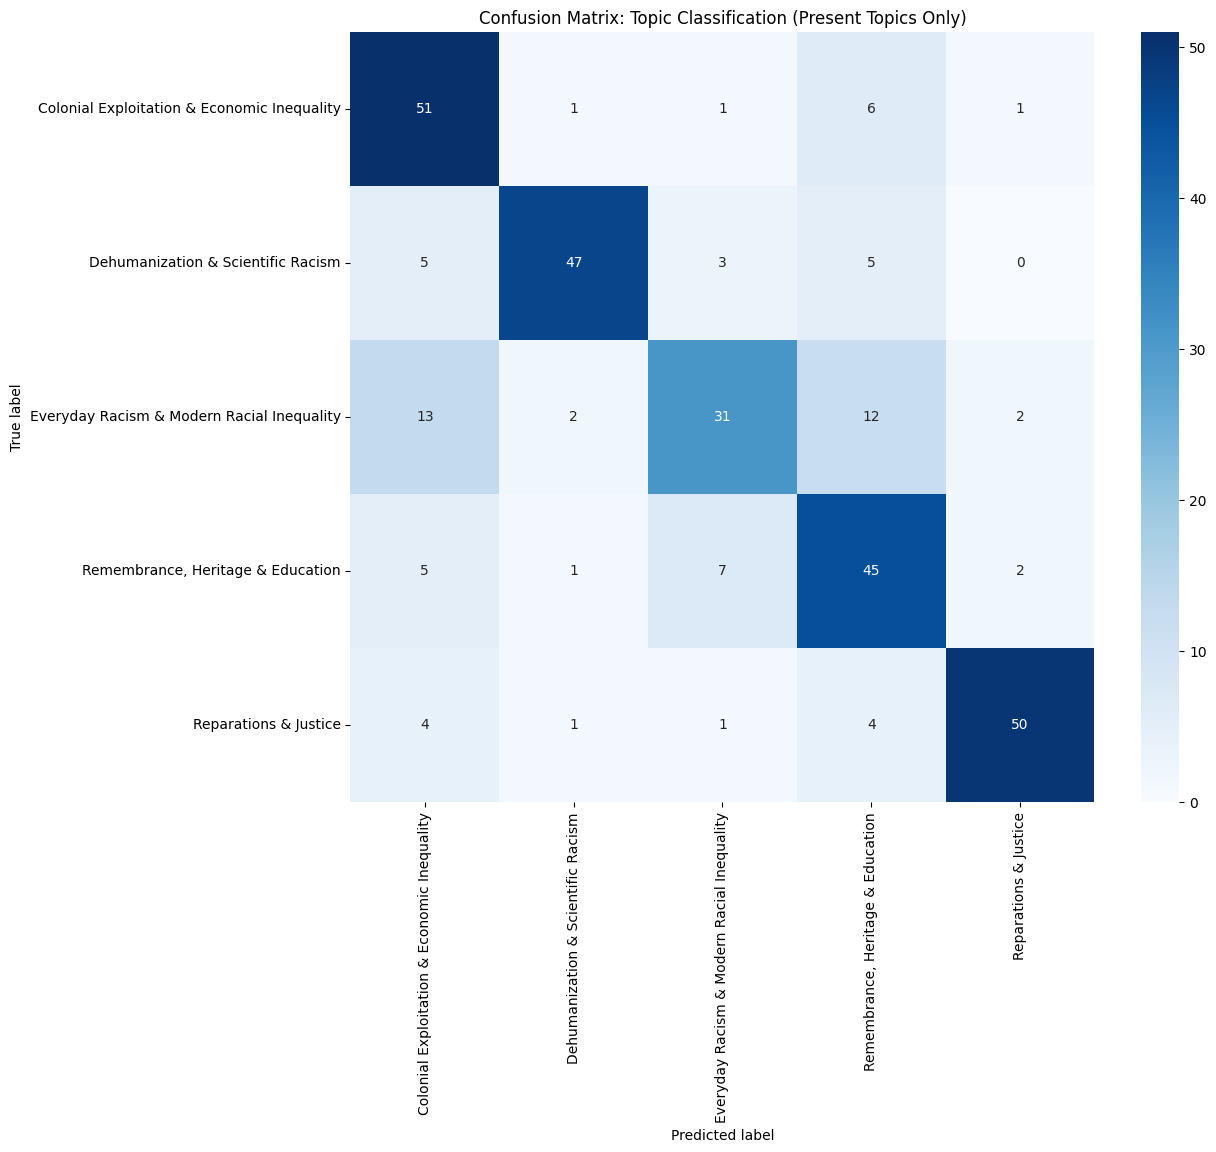

In [70]:
import os
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import classification_report
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Prepare DataFrame and Encode Labels ---
# matched_df should have columns: 'sentence' and 'topic'
le = LabelEncoder()
train_source['label'] = le.fit_transform(train_source['topic'])

# Split your data (replace with your split method)
# Example:
# train_df = matched_df.sample(frac=0.8, random_state=42)
# val_df = matched_df.drop(train_df.index)

# (If you already have train_df/val_df with the correct 'label' column, continue)

# Build label2topic and topic2label for reference
label2topic = dict(zip(le.transform(le.classes_), le.classes_))
topic2label = dict(zip(le.classes_, le.transform(le.classes_)))
print("label2topic:", label2topic)

with open('slavery-label2topic.pickle', 'wb') as fp:
    pickle.dump(label2topic, fp, protocol=pickle.HIGHEST_PROTOCOL)

with open('slavery-topic2label.pickle', 'wb') as fp:
    pickle.dump(topic2label, fp, protocol=pickle.HIGHEST_PROTOCOL)



# --- 2. Convert to HuggingFace Datasets ---
train_dataset = Dataset.from_pandas(train_df)
val_dataset = Dataset.from_pandas(val_df)

# --- 3. Tokenization ---
MODEL_NAME = "GroNLP/bert-base-dutch-cased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_function(batch):
    return tokenizer(batch["chunk_text"], padding="max_length", truncation=True, max_length=128)

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

# --- 4. Model Setup ---
num_labels = len(label2topic)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=num_labels)

# --- 5. TrainingArguments ---
os.environ["WANDB_DISABLED"] = "true"
training_args = TrainingArguments(
    output_dir="./bertje_slavery",
    eval_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss"
)

def compute_metrics(eval_pred):
    from sklearn.metrics import accuracy_score, f1_score
    logits, labels = eval_pred
    preds = logits.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

# --- 6. Trainer ---
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
)

# --- 7. Training ---
trainer.train()

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# After prediction:
eval_results = trainer.predict(val_dataset)
pred_labels = np.argmax(eval_results.predictions, axis=1)
true_labels = eval_results.label_ids

# --- Safe label/name selection for reporting ---
# Only include labels actually present in y_true or y_pred, and that exist in label2topic
unique_labels = sorted(set(np.unique(true_labels)).union(np.unique(pred_labels)))
all_labels = [l for l in unique_labels if l in label2topic]
all_names = [label2topic[l] for l in all_labels]

# Per-class report (always aligned to what's present)
print(classification_report(
    true_labels,
    pred_labels,
    labels=all_labels,
    target_names=all_names,
    zero_division=0
))

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels, labels=all_labels)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=all_names, yticklabels=all_names, cmap="Blues")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: Topic Classification (Present Topics Only)")
plt.show()

# -- Save your full mappings for future use --
import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open('policy-label2topic.pickle', 'wb') as fp:
    pickle.dump(label2topic, fp, protocol=pickle.HIGHEST_PROTOCOL)
with open('policy-topic2label.pickle', 'wb') as fp:
    pickle.dump(topic2label, fp, protocol=pickle.HIGHEST_PROTOCOL)

Bertje model evaluation

In [ ]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import numpy as np

# Load tokenizer and model
model_name_or_path = './bertje_slavery/checkpoint-225'  # e.g., './output_dir'
tokenizer = BertTokenizer.from_pretrained("groNLP/bert-base-dutch-cased")
model = BertForSequenceClassification.from_pretrained(model_name_or_path)
model.eval()

# Define your label mapping (adjust to your actual label order)
labels = [
    'Colonial Exploitation & Economic Inequality',
    'Dehumanization & Scientific Racism',
    'Everyday Racism & Modern Racial Inequality',
    'Reparations & Justice'
]

def predict_topic(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits
        probs = torch.softmax(logits, dim=1).numpy().flatten()
        pred_idx = np.argmax(probs)
        return labels[pred_idx], probs[pred_idx], probs

# Example
sentence = "reparaties"
topic, confidence, all_probs = predict_topic(sentence)
print(f"Predicted topic: {topic} (Confidence: {confidence:.2f})")
print("All topic probabilities:", dict(zip(labels, all_probs.round(5))))


Predicted topic: Everyday Racism & Modern Racial Inequality (Confidence: 0.57)
All topic probabilities: {'Colonial Exploitation & Economic Inequality': np.float32(0.11239), 'Dehumanization & Scientific Racism': np.float32(0.06152), 'Everyday Racism & Modern Racial Inequality': np.float32(0.56693), 'Reparations & Justice': np.float32(0.02779)}


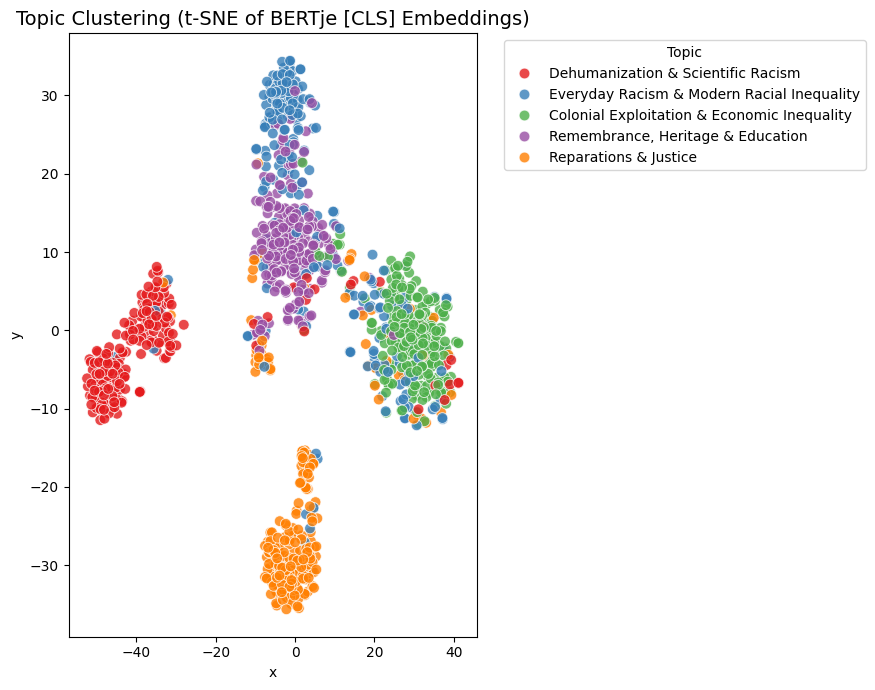

In [80]:
import torch
import numpy as np
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- SETUP ----
model_path = './bertje_slavery/checkpoint-225'
tokenizer = BertTokenizer.from_pretrained('GroNLP/bert-base-dutch-cased')
model = BertForSequenceClassification.from_pretrained(model_path)
model.eval()

# 2. Load your data (texts and labels)
texts = train_dataset['chunk_text']  # List of texts
label_ids = train_dataset['label']   # List of int label ids

# Provide your mapping from label id to topic name:
label2topic = {
    0: 'Colonial Exploitation & Economic Inequality',
    1: 'Dehumanization & Scientific Racism',
    2: 'Everyday Racism & Modern Racial Inequality',
    3: 'Remembrance, Heritage & Education',
    4: 'Reparations & Justice'
}

y_true = [label2topic[i] for i in label_ids]
labels = [label2topic[i] for i in sorted(label2topic.keys())]  # All possible topic names

# ---- EMBEDDING EXTRACTION ----
def get_embedding(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model.bert(**inputs)
        return outputs.last_hidden_state[:,0,:].squeeze().numpy()

# Fix here: Should loop over `texts`, not 'chunk_text' string
embeddings = np.array([get_embedding(t) for t in texts])

# ---- t-SNE REDUCTION ----
perplexity = min(30, len(embeddings)-1)  # Avoid ValueError if dataset is small
tsne = TSNE(n_components=2, random_state=0, perplexity=perplexity)
reduced = tsne.fit_transform(embeddings)

df = pd.DataFrame({
    'x': reduced[:,0],
    'y': reduced[:,1],
    'label': y_true
})

# ---- PLOTTING ----
plt.figure(figsize=(9,7))
sns.scatterplot(data=df, x='x', y='y', hue='label', palette='Set1', s=60, alpha=0.8)
plt.title("Topic Clustering (t-SNE of BERTje [CLS] Embeddings)", fontsize=14)
plt.legend(title="Topic", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


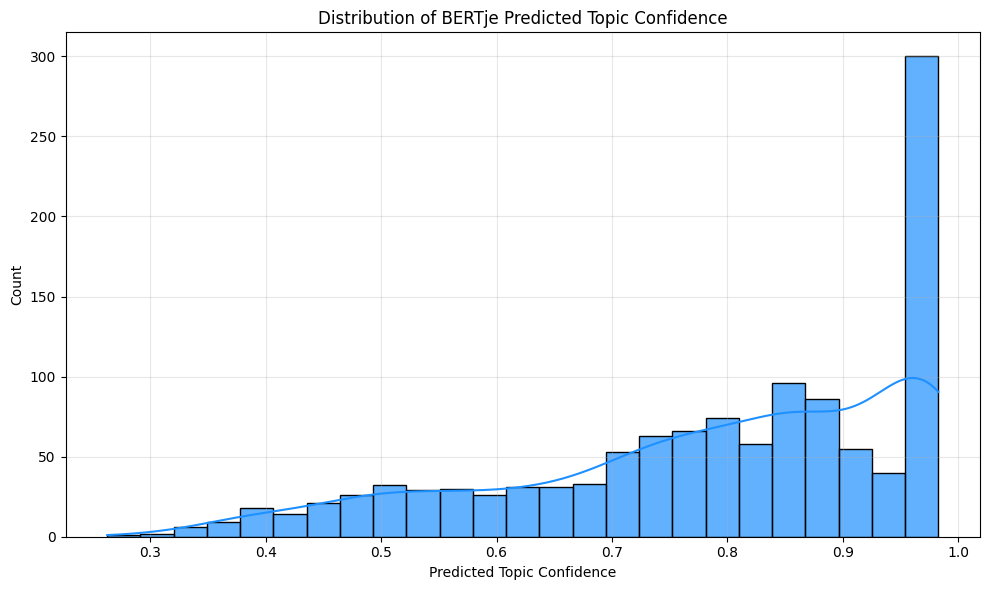

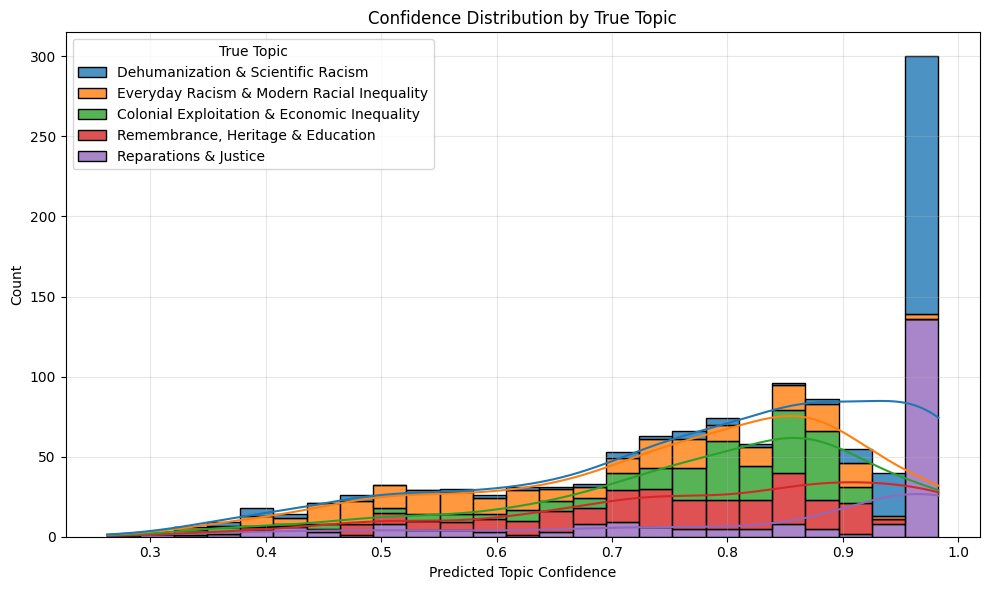

In [82]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BertTokenizer, BertForSequenceClassification

# ---- SETUP ----
model_path = './bertje_slavery/checkpoint-225'
tokenizer = BertTokenizer.from_pretrained('GroNLP/bert-base-dutch-cased')
model = BertForSequenceClassification.from_pretrained(model_path)
model.eval()

# Load data
texts = train_dataset['chunk_text']  # List of texts
label_ids = train_dataset['label']   # List of int label ids

label2topic = {
    0: 'Colonial Exploitation & Economic Inequality',
    1: 'Dehumanization & Scientific Racism',
    2: 'Everyday Racism & Modern Racial Inequality',
    3: 'Remembrance, Heritage & Education',
    4: 'Reparations & Justice'
}
topic_names = [label2topic[i] for i in sorted(label2topic.keys())]
y_true = [label2topic[i] for i in label_ids]

# ---- CONFIDENCE EXTRACTION ----
def get_confidence(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=256)
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=1).numpy().flatten()
        pred_idx = np.argmax(probs)
        confidence = probs[pred_idx]
        return confidence, pred_idx, probs

confidences = []
true_labels = []
predicted_labels = []

for text, true_id in zip(texts, label_ids):
    conf, pred_idx, _ = get_confidence(text)
    confidences.append(conf)
    true_labels.append(label2topic[true_id])
    predicted_labels.append(label2topic[pred_idx])

# ---- PLOT CONFIDENCE DISTRIBUTION ----
plt.figure(figsize=(10,6))
sns.histplot(confidences, bins=25, kde=True, color='dodgerblue', alpha=0.7)
plt.xlabel('Predicted Topic Confidence')
plt.ylabel('Count')
plt.title('Distribution of BERTje Predicted Topic Confidence')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- OPTIONAL: Breakdown by True Topic ----
plt.figure(figsize=(10,6))
sns.histplot(data=pd.DataFrame({'Confidence': confidences, 'True Topic': true_labels}),
             x='Confidence', hue='True Topic', bins=25, kde=True, multiple='stack', alpha=0.8)
plt.xlabel('Predicted Topic Confidence')
plt.ylabel('Count')
plt.title('Confidence Distribution by True Topic')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [87]:
import pandas as pd
pd.set_option('display.max_colwidth', None)
  # Increase to 300 chars (or any large number)

# After collecting confidences, texts, and true_labels:
df = pd.DataFrame({'confidence': confidences, 'text': texts, 'true_label': true_labels, 'pred_label': predicted_labels})

# Sort by confidence
high_conf_threshold = df['confidence'].quantile(0.90)
df_high = df[df['confidence'] >= high_conf_threshold]
print(df_high[['confidence', 'true_label', 'pred_label', 'text']])



      confidence                          true_label  \
0       0.978373  Dehumanization & Scientific Racism   
3       0.981926  Dehumanization & Scientific Racism   
31      0.982717  Dehumanization & Scientific Racism   
37      0.981613  Dehumanization & Scientific Racism   
52      0.981703  Dehumanization & Scientific Racism   
...          ...                                 ...   
1108    0.981666  Dehumanization & Scientific Racism   
1111    0.979449  Dehumanization & Scientific Racism   
1120    0.982670  Dehumanization & Scientific Racism   
1155    0.980951  Dehumanization & Scientific Racism   
1157    0.980034  Dehumanization & Scientific Racism   

                              pred_label  \
0     Dehumanization & Scientific Racism   
3     Dehumanization & Scientific Racism   
31    Dehumanization & Scientific Racism   
37    Dehumanization & Scientific Racism   
52    Dehumanization & Scientific Racism   
...                                  ...   
1108  Dehumanizatio